# Twitter Emoji Prediction

## 1. Data Exploration

### 1.1 Load the CSV files

In [2]:
import pandas as pd


train = pd.read_csv("/kaggle/input/twitter-emoji-prediction/Train.csv")
test = pd.read_csv("/kaggle/input/twitter-emoji-prediction/Test.csv")
mapping = pd.read_csv("/kaggle/input/twitter-emoji-prediction/Mapping.csv")

print("Train Data:")
display(train.head())

print("Test Data:")
display(test.head())

print("Mapping Data:")
display(mapping.head())


Train Data:


,Unnamed: 0,TEXT,Label
0,0,Vacation wasted ! #vacation2017 #photobomb #ti...,0
1,1,"Oh Wynwood, you’re so funny! : @user #Wynwood ...",1
2,2,Been friends since 7th grade. Look at us now w...,2
3,3,This is what it looks like when someone loves ...,3
4,4,RT @user this white family was invited to a Bl...,3


Test Data:


,Unnamed: 0,id,TEXT
0,0,0,Thought this was cool...#Repost (get_repost)・・...
1,1,1,Happy 4th! Corte madera parade. #everytownusa ...
2,2,2,Luv. Or at least something close to it. @ Unio...
3,3,3,There's a slice of pie under that whipped crea...
4,5,5,#thankyou for your thank you We adore you both...


Mapping Data:


,Unnamed: 0,emoticons,number
0,0,😜,0
1,1,📸,1
2,2,😍,2
3,3,😂,3
4,4,😉,4


### 1.2 Dataset size and info

In [4]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Mapping shape:", mapping.shape)


print("Missing values in train:\n", train.isnull().sum())
print("Missing values in test:\n", test.isnull().sum())
print("Missing values in map:\n", mapping.isnull().sum())

Train shape: (70000, 3)
Test shape: (25958, 3)
Mapping shape: (20, 3)
Missing values in train:
 Unnamed: 0    0
TEXT          0
Label         0
dtype: int64
Missing values in test:
 Unnamed: 0    0
id            0
TEXT          0
dtype: int64
Missing values in map:
 Unnamed: 0    0
emoticons     0
number        0
dtype: int64


### 1.3 Explore class distribution

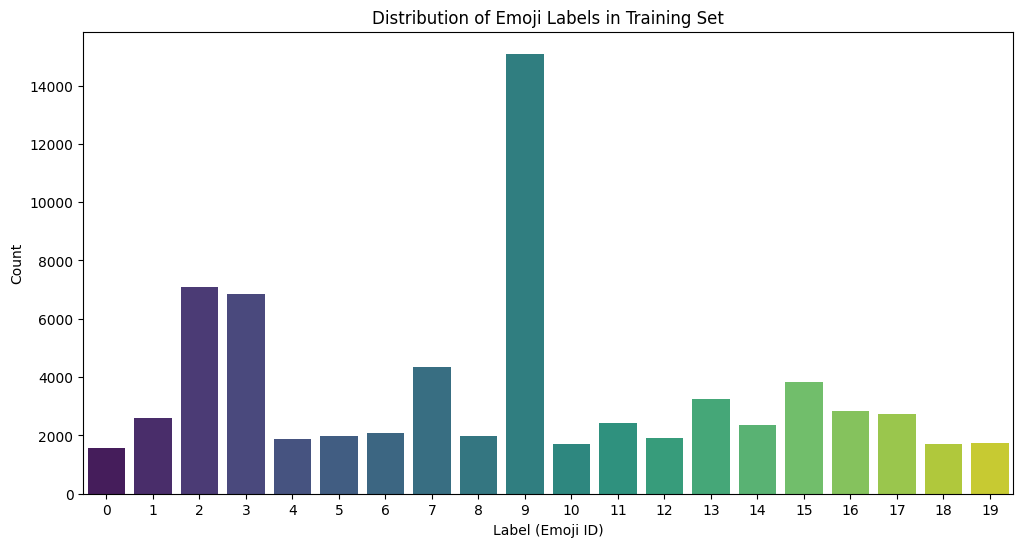

In [5]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("plots", exist_ok=True)

label_counts = train['Label'].value_counts().sort_index()

plt.figure(figsize=(12,6))
sns.barplot(x=label_counts.index, y=label_counts.values, palette="viridis")
plt.title("Distribution of Emoji Labels in Training Set")
plt.xlabel("Label (Emoji ID)")
plt.ylabel("Count")

plt.savefig("plots/class_distribution.png", dpi=300)
plt.show()
plt.close()

### 1.4 Tweet Length Distribution


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


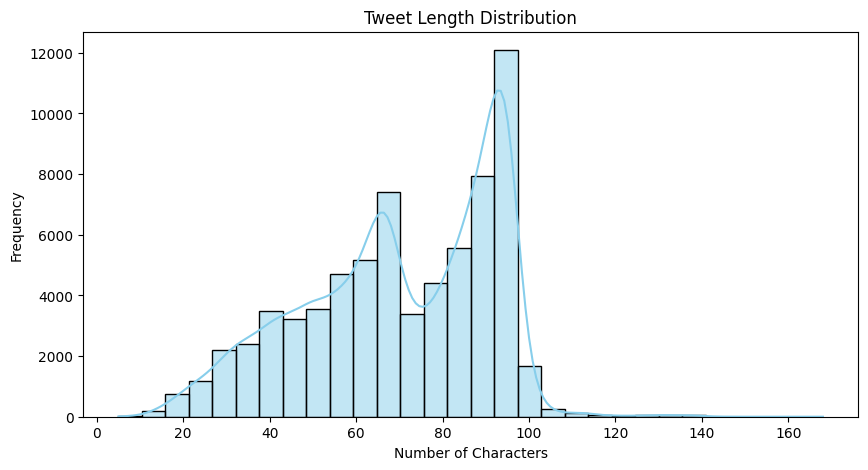

count    70000.000000
mean        70.008171
std         21.868925
min          5.000000
25%         54.000000
50%         71.000000
75%         90.000000
max        168.000000
Name: tweet_length, dtype: float64


In [8]:
train['tweet_length'] = train['TEXT'].astype(str).apply(len)


plt.figure(figsize=(10, 5))
sns.histplot(train['tweet_length'], bins=30, kde=True, color='skyblue')
plt.title("Tweet Length Distribution")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")

plt.savefig("plots/tweet_length_distribution.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print(train['tweet_length'].describe())
